# Concatenating, Joining, and Pivoting Data

There are several ways of answering many questions in this notebook, but try to use the new operations (concatenate, joint/merge, pivot) whenever possible to get practice.

In [56]:
import pandas as pd

## Movie Ratings Data

The Movielens data set (https://dlsun.github.io/pods/data/ml-1m/ ) contains 1 million movie ratings submitted by users. The information about the movies, ratings, and users are stored in three separate files, called `movies.dat`, `ratings.dat`, and `users.dat`. The column names are not included with the data files. Refer to the webpage above for more information.


1\. Read in each of the data files.


(Hint: see the note in the documentation about the delimiter; use the `sep` argument in `read_csv`. If you get an error when reading the `movies.dat` file, try `encoding_errors = "ignore"` in `read_csv`.)

In [57]:
base = "https://dlsun.github.io/pods/data/ml-1m/"

movies_url = base + "movies.dat"
movies = pd.read_csv(movies_url, sep = "::", encoding_errors= "ignore", header = None, names = ["movies_id", "title","genre"])

ratings_url = base + "ratings.dat"
ratings = pd.read_csv(ratings_url, sep = "::", encoding_errors= "ignore", header = None, names = ["user_id", "movie_id", "rating", "timestamp"])

users_url = base + "users.dat"
users = pd.read_csv(users_url, sep = "::", encoding_errors="ignore", header = None, names=["user_id", "gender", "age", "occupation", "zip"])

<positron-console-cell-57>:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-57>:7: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
<positron-console-cell-57>:10: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.


2\. Which age group tends to give the highest ratings? Create an appropriate summary to answer this question.

(Note the way age is coded in the [REAMDE file](https://dlsun.github.io/pods/data/ml-1m/README.txt).)

In [58]:
ratings_users_df = ratings.merge(users, on = "user_id", how = "left", validate = "many_to_one")
age_label = {1:"<18", 18:"18-24", 25:"25-34", 35:"35-44", 45:"45-49", 50:"50-55", 56:"56+"}
ratings_users_df["age_group"] = ratings_users_df["age"].map(age_label)
ratings_users_df.groupby("age_group")["rating"].agg(n_rating = "size", mean_rating = "mean").sort_values("mean_rating", ascending = False).reset_index()

,age_group,n_rating,mean_rating
0,56+,38780,3.766632
1,50-55,72490,3.714512
2,45-49,83633,3.638062
3,35-44,199003,3.618162
4,<18,27211,3.549520
5,25-34,395556,3.545235
6,18-24,183536,3.507573


3\. Among movies with at least 100 ratings, which movies had the highest average rating? The lowest?

In [59]:
stats = ratings.groupby("movie_id").agg(avg=("rating", "mean"), count=("rating", "count"))
merged = stats[stats["count"] >= 100].join(movies.set_index("movies_id"))
print("Highest:", merged.sort_values("avg", ascending=False).iloc[0]["title"])
print("Lowest:", merged.sort_values("avg").iloc[0]["title"])

Highest: Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)
Lowest: Kazaam (1996)


4\. For each movie, calculate the average rating and the proportion of the ratings that were from users aged 18-24. Make a scatterplot showing the relationship between the average rating and the 18-24 share, with each point representing a movie. (Optional: Use the size of each point to represent the number of users who rated the movie.)

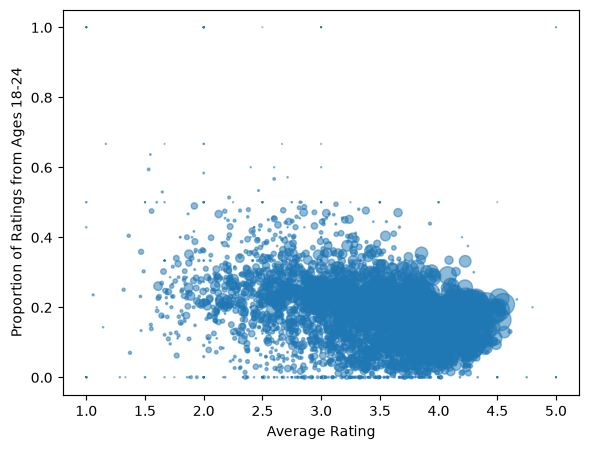

In [63]:
import matplotlib.pyplot as plt

df = ratings.merge(users, on="user_id")
stats = (
    df.assign(is_18_24=df["age"] == 18)
    .groupby("movie_id")
    .agg(avg=("rating", "mean"), share=("is_18_24", "mean"), count=("rating", "count"))
)

stats.plot.scatter(x="avg", y="share", s=stats["count"] * 0.1, alpha=0.5)
plt.xlabel("Average Rating")
plt.ylabel("Proportion of Ratings from Ages 18-24")
plt.show()

5\. Calculate the number of ratings by movie. How many of the movies had zero ratings?

(_Hint_: Why is an inner join not sufficient here?)

In [61]:
counts = ratings.groupby("movie_id").size()
print("Zero ratings:", (movies.set_index("movies_id").assign(count=counts).fillna(0)["count"] == 0).sum())

Zero ratings: 177


6\. How many movies received both a 1 and a 5 rating? Which movies? How many ratings of each type (1 or 5 stars)? Answer these question by joining two appropriate tables.

In [62]:
ones = ratings[ratings["rating"] == 1]["movie_id"].drop_duplicates()
fives = ratings[ratings["rating"] == 5]["movie_id"].drop_duplicates()

both_1_and_5 = pd.merge(ones, fives, on="movie_id")

rating_breakdown = (
    ratings[ratings["movie_id"].isin(both_1_and_5["movie_id"]) & ratings["rating"].isin([1, 5])]
    .groupby(["movie_id", "rating"])
    .size()
    .unstack(fill_value=0)
)
rating_breakdown.columns = ["count_1_star", "count_5_star"]

print(rating_breakdown.head())

          count_1_star  count_5_star
movie_id                            
1                   16           820
2                   42            48
3                   44            43
4                   21             6
5                   28            16
